In [3]:
import shap
import matplotlib.pyplot as plt

# Initialize JS visualization (optional for notebooks)
shap.initjs()

In [33]:
import joblib

best_lgb = joblib.load("../models/test1/best_lgb.pkl")

In [34]:
explainer = shap.TreeExplainer(best_lgb)

In [35]:
import pandas as pd
X_train_smote = pd.read_csv("../data/processed/X_train_smote.csv")
y_train_smote = pd.read_csv("../data/processed/y_train_smote.csv").squeeze()
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [36]:
X_test = X_test.drop(columns=["Satisfaction Score", ])

In [37]:
shap_values = explainer(X_test)

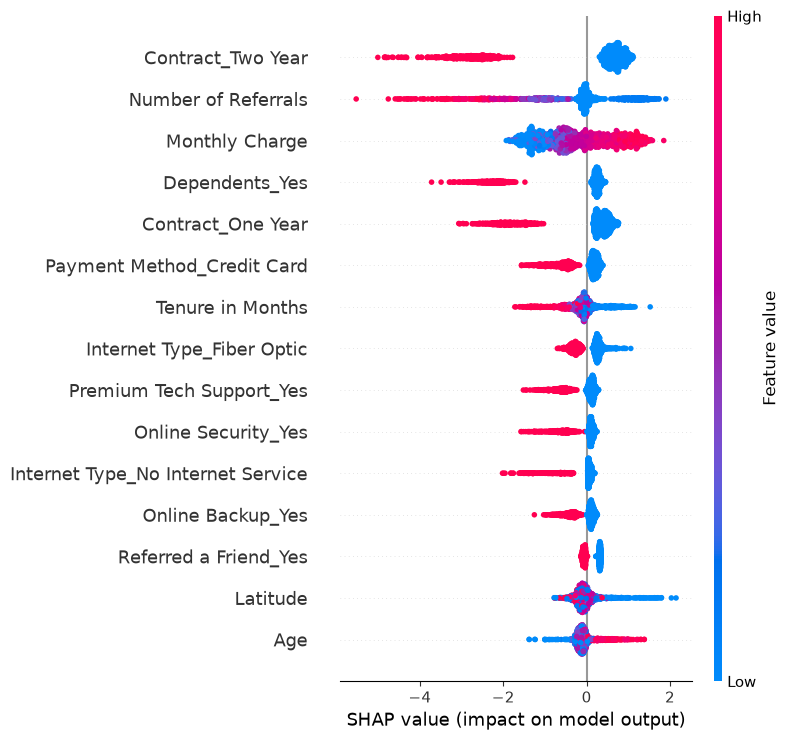

In [38]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)

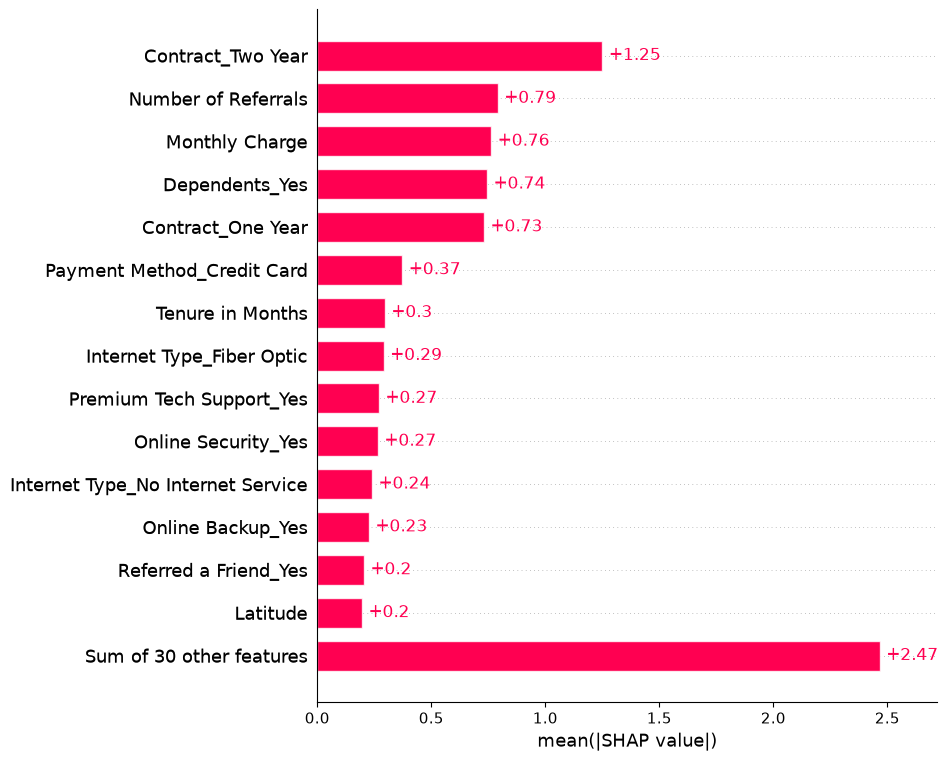

In [39]:
shap.plots.bar(
    shap_values,
    max_display=15
)

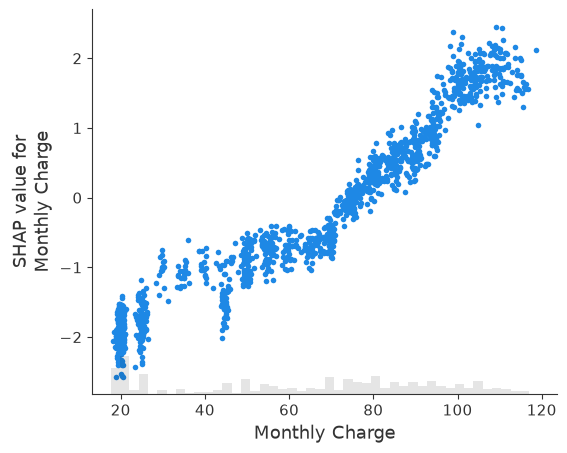

In [11]:
shap.plots.scatter(
    shap_values[:, "Monthly Charge"],
)

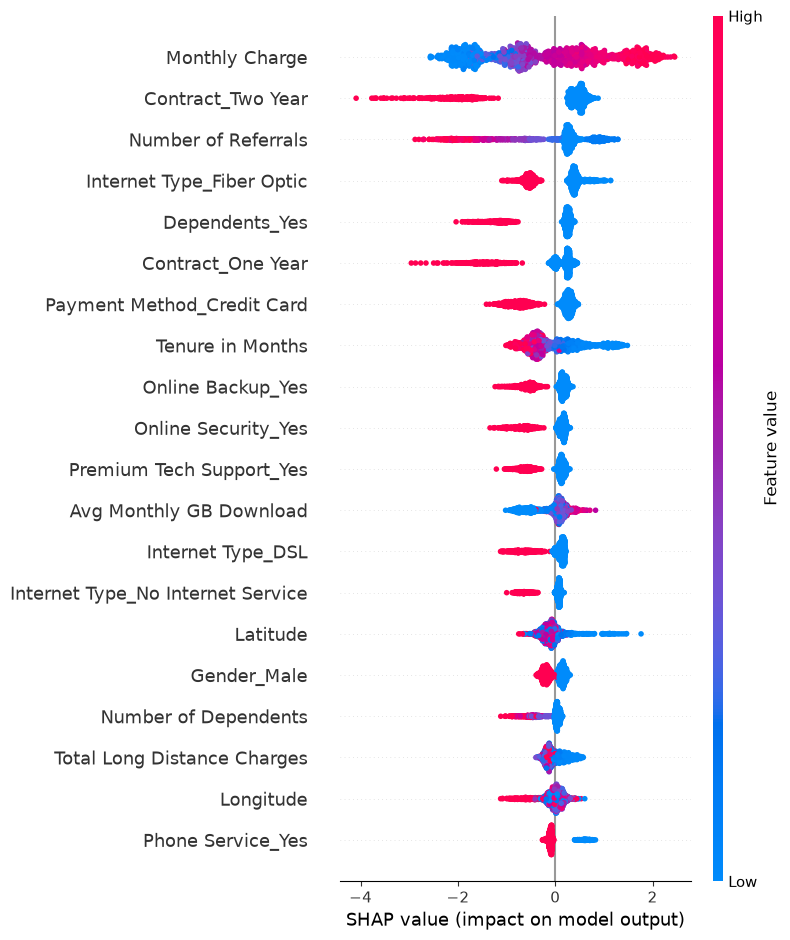

In [12]:
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig("../figures/test_global_shap_summary.png", dpi=300)
plt.show()

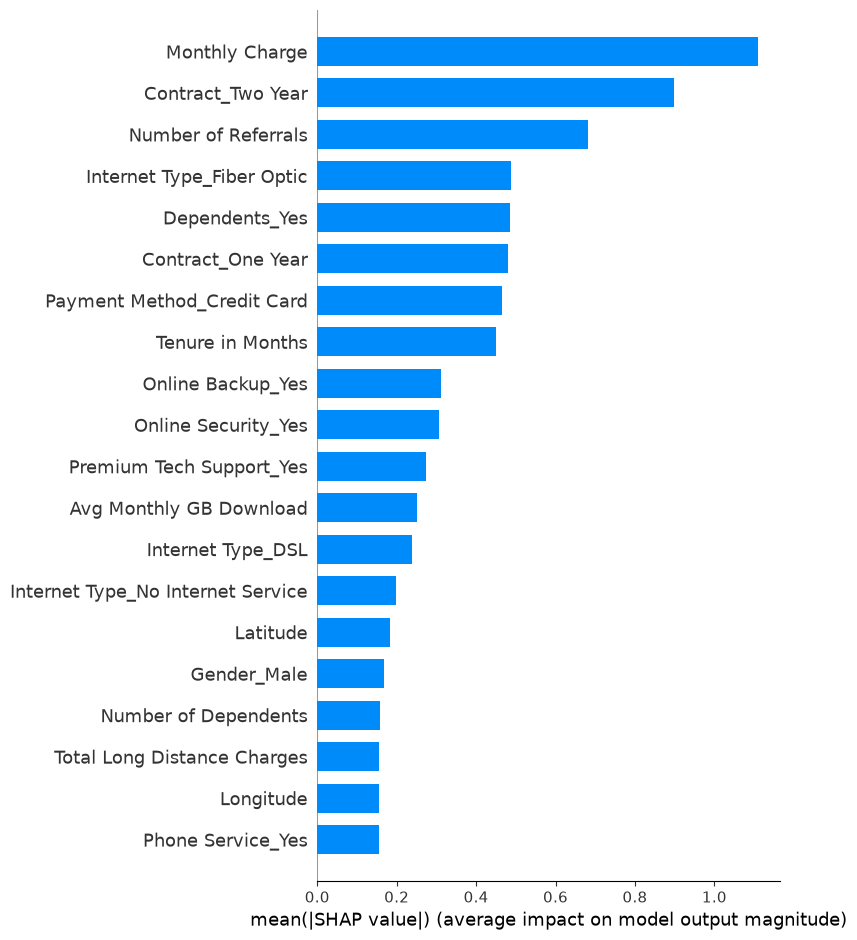

In [13]:
plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("../figures/test_global_shap_bar.png", dpi=300)
plt.show()

In [14]:
import joblib

voting_clf = joblib.load("../models/test1/soft_voting.pkl")

In [15]:

X_train_smote = X_train_smote.drop(columns=["Satisfaction Score",])

In [16]:
import shap
import numpy as np
feature_names = X_train_smote.columns

def predict_fn(x):
    x = pd.DataFrame(x, columns=feature_names)
    return voting_clf.predict_proba(x)

background = shap.sample(X_train_smote, 100, random_state=42)

explainer = shap.KernelExplainer(
    predict_fn,
    background
)

In [17]:
X_test_sample = X_test.sample(100, random_state=42)
shap_values = explainer.shap_values(
    X_test_sample,
    nsamples=200
)

  0%|          | 0/100 [00:00<?, ?it/s]

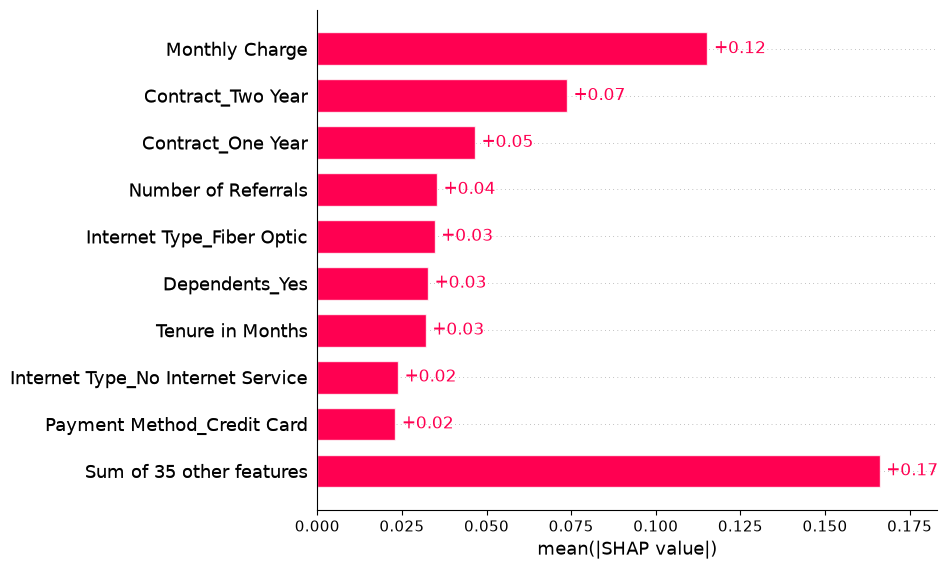

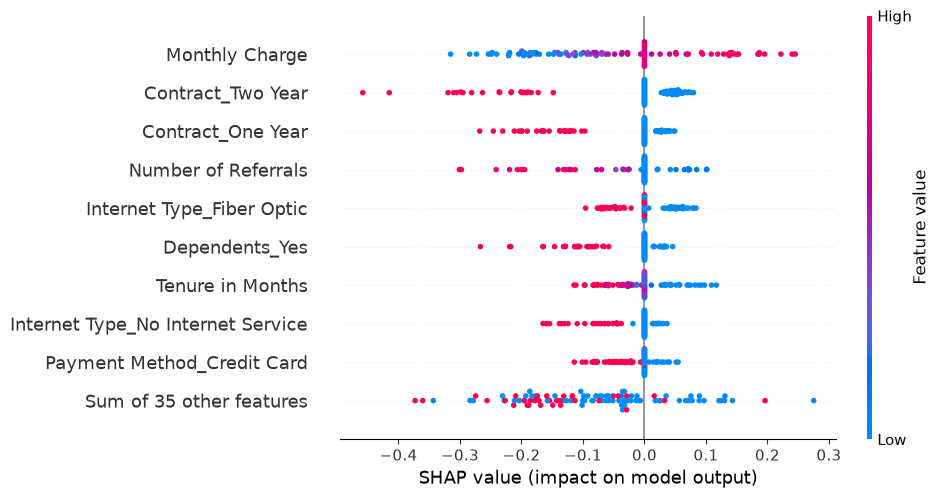

In [18]:
explanation = shap.Explanation(
    values=shap_values[:, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_sample.values,
    feature_names=X_test_sample.columns
)

shap.plots.bar(explanation)
shap.plots.beeswarm(explanation)

In [19]:
cluster0 = pd.read_csv("../data/cluster0.csv")
cluster1 = pd.read_csv("../data/cluster1.csv")

In [21]:
cluster0= cluster0.drop(columns=[
    "Churn Label",
    "Cluster",
    "Satisfaction Score"
])

cluster1 = cluster1.drop(columns=[
    "Churn Label",
    "Cluster",
    "Satisfaction Score"
])

In [22]:
cluster0_sample = cluster0.sample(100, random_state=42)
cluster1_sample = cluster1.sample(100, random_state=42)

shap_cluster0 = explainer.shap_values(cluster0_sample, nsamples=200)
shap_cluster1 = explainer.shap_values(cluster1_sample, nsamples=200)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [23]:
import pandas as pd
import numpy as np

global_importance = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "Mean |SHAP|": np.abs(shap_values[:, :, 1]).mean(axis=0)
})

global_importance = global_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

global_importance.head(15)

,Feature,Mean |SHAP|
9,Monthly Charge,0.115257
40,Contract_Two Year,0.073747
39,Contract_One Year,0.046568
5,Number of Referrals,0.035358
29,Internet Type_Fiber Optic,0.034658
18,Dependents_Yes,0.032713
6,Tenure in Months,0.032032
30,Internet Type_No Internet Service,0.023844
42,Payment Method_Credit Card,0.023029
31,Online Security_Yes,0.019680


In [24]:
cluster0_importance = pd.DataFrame({
    "Feature": cluster0.columns,
    "Mean |SHAP|": np.abs(shap_cluster0[:, :, 1]).mean(axis=0)
})

cluster0_importance = cluster0_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

cluster0_importance.head(15)

,Feature,Mean |SHAP|
9,Monthly Charge,0.082242
40,Contract_Two Year,0.068110
39,Contract_One Year,0.055584
5,Number of Referrals,0.042433
6,Tenure in Months,0.036385
31,Online Security_Yes,0.024174
29,Internet Type_Fiber Optic,0.023604
18,Dependents_Yes,0.023473
42,Payment Method_Credit Card,0.019828
28,Internet Type_DSL,0.018556


In [25]:
cluster1_importance = pd.DataFrame({
    "Feature": cluster1.columns,
    "Mean |SHAP|": np.abs(shap_cluster1[:, :, 1]).mean(axis=0)
})

cluster1_importance = cluster1_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

cluster1_importance.head(15)

,Feature,Mean |SHAP|
9,Monthly Charge,0.201965
40,Contract_Two Year,0.098868
30,Internet Type_No Internet Service,0.078427
18,Dependents_Yes,0.036840
39,Contract_One Year,0.036619
5,Number of Referrals,0.031097
42,Payment Method_Credit Card,0.030070
29,Internet Type_Fiber Optic,0.027220
8,Avg Monthly GB Download,0.024419
6,Tenure in Months,0.023545


In [26]:
comparison = pd.DataFrame({
    "Global": global_importance["Feature"].head(10).values,
    "Cluster 0": cluster0_importance["Feature"].head(10).values,
    "Cluster 1": cluster1_importance["Feature"].head(10).values
})

comparison

,Global,Cluster 0,Cluster 1
0,Monthly Charge,Monthly Charge,Monthly Charge
1,Contract_Two Year,Contract_Two Year,Contract_Two Year
2,Contract_One Year,Contract_One Year,Internet Type_No Internet Service
3,Number of Referrals,Number of Referrals,Dependents_Yes
4,Internet Type_Fiber Optic,Tenure in Months,Contract_One Year
5,Dependents_Yes,Online Security_Yes,Number of Referrals
6,Tenure in Months,Internet Type_Fiber Optic,Payment Method_Credit Card
7,Internet Type_No Internet Service,Dependents_Yes,Internet Type_Fiber Optic
8,Payment Method_Credit Card,Payment Method_Credit Card,Avg Monthly GB Download
9,Online Security_Yes,Internet Type_DSL,Tenure in Months


In [27]:
global_importance.to_csv("../results/test_global_shap.csv", index=False)

cluster0_importance.to_csv("../results/test_cluster0_shap.csv", index=False)

cluster1_importance.to_csv("../results/test_cluster1_shap.csv", index=False)

In [28]:
rank_global = global_importance.reset_index(drop=True)
rank_global["Global Rank"] = rank_global.index + 1

rank_cluster0 = cluster0_importance.reset_index(drop=True)
rank_cluster0["Cluster0 Rank"] = rank_cluster0.index + 1

rank_cluster1 = cluster1_importance.reset_index(drop=True)
rank_cluster1["Cluster1 Rank"] = rank_cluster1.index + 1

comparison_rank = (
    rank_global[["Feature","Global Rank"]]
    .merge(rank_cluster0[["Feature","Cluster0 Rank"]], on="Feature")
    .merge(rank_cluster1[["Feature","Cluster1 Rank"]], on="Feature")
)

comparison_rank

,Feature,Global Rank,Cluster0 Rank,Cluster1 Rank
0,Monthly Charge,1,1,1
1,Contract_Two Year,2,2,2
2,Contract_One Year,3,3,5
3,Number of Referrals,4,4,6
4,Internet Type_Fiber Optic,5,7,8
5,Dependents_Yes,6,8,4
6,Tenure in Months,7,5,10
7,Internet Type_No Internet Service,8,34,3
8,Payment Method_Credit Card,9,9,7
9,Online Security_Yes,10,6,20


In [29]:
comparison_rank["Rank Difference"] = (
    comparison_rank["Cluster0 Rank"] -
    comparison_rank["Cluster1 Rank"]
).abs()

comparison_rank.sort_values(
    "Rank Difference",
    ascending=False
).head(15)

,Feature,Global Rank,Cluster0 Rank,Cluster1 Rank,Rank Difference
7,Internet Type_No Internet Service,8,34,3,31
12,Online Backup_Yes,13,12,43,31
18,Internet Service_Yes,19,39,11,28
11,Internet Type_DSL,12,10,31,21
10,Premium Tech Support_Yes,11,11,28,17
14,Avg Monthly GB Download,15,25,9,16
30,Streaming Movies_Yes,31,27,41,14
9,Online Security_Yes,10,6,20,14
38,Streaming Music_Yes,39,26,39,13
29,Streaming TV_Yes,30,21,33,12


In [30]:
corr = np.corrcoef(
    global_importance["Mean |SHAP|"],
    cluster0_importance["Mean |SHAP|"]
)[0,1]

print(corr)

0.9741661398107562


In [31]:
corr = np.corrcoef(
    global_importance["Mean |SHAP|"],
    cluster1_importance["Mean |SHAP|"]
)[0,1]

print(corr)

0.9735261510804639


In [32]:
corr = np.corrcoef(
    cluster1_importance["Mean |SHAP|"],
    cluster0_importance["Mean |SHAP|"]
)[0,1]

print(corr)

0.9343893928806023
